<font color="#2563EB"><strong>🍒 CH3RRY PI3 · DATA SCIENCE LEARNING LAB</strong></font>

# <font color="#4DAAFC"><strong>Feature Scaling: Why Units Change Gradient Descent</strong></font>

A floor area measured in square metres and a building age measured in years can both help predict a price—but their numerical ranges are very different. Gradient descent responds to those numbers, not merely to their meanings. This Learning Lab makes that effect visible and then builds a safe, reusable standardisation workflow from first principles.

We will frame the units problem, derive standardisation, calculate one example by hand, implement it with NumPy, compare raw and scaled optimisation, restore the final coefficients to their original units and finish with checks and limitations.

**Intended audience:** beginning data scientists and data analysts who want to understand preprocessing rather than merely call it  
**Prerequisites:** basic Python and NumPy; means and square roots; linear predictions; a first encounter with gradients  
**Estimated study time:** 75–90 minutes  
**Last reviewed:** 14 August 2026


## <font color="#4DAAFC"><strong>Learning journey</strong></font>

**[Frame the units problem](#problem)** &rarr; **[Derive standardisation](#standardisation)** &rarr; **[Calculate it by hand](#worked-example)** &rarr; **[Build a safe transformer](#transformer)** &rarr; **[Compare optimisation](#comparison)** &rarr; **[Restore original units](#original-units)** &rarr; **[Validate and reflect](#checks)**

<table>
<thead><tr><th align="left"><font size="3">Stage</font></th><th align="left"><font size="3">Question answered</font></th><th align="left"><font size="3">Main section</font></th></tr></thead>
<tbody>
<tr><td align="left"><font size="3">1. Frame</font></td><td align="left"><font size="3">Why can units affect an optimiser?</font></td><td align="left"><font size="3"><a href="#problem">Section 2</a></font></td></tr>
<tr><td align="left"><font size="3">2. Formalise</font></td><td align="left"><font size="3">What exactly does standardisation calculate?</font></td><td align="left"><font size="3"><a href="#standardisation">Section 3</a></font></td></tr>
<tr><td align="left"><font size="3">3. Calculate</font></td><td align="left"><font size="3">Can we reproduce the transform by hand?</font></td><td align="left"><font size="3"><a href="#worked-example">Section 4</a></font></td></tr>
<tr><td align="left"><font size="3">4. Build</font></td><td align="left"><font size="3">How do we fit and apply it without leakage?</font></td><td align="left"><font size="3"><a href="#transformer">Section 5</a></font></td></tr>
<tr><td align="left"><font size="3">5. Compare</font></td><td align="left"><font size="3">What changes during gradient descent?</font></td><td align="left"><font size="3"><a href="#comparison">Sections 6–7</a></font></td></tr>
<tr><td align="left"><font size="3">6. Interpret</font></td><td align="left"><font size="3">How do we recover coefficients in familiar units?</font></td><td align="left"><font size="3"><a href="#original-units">Section 8</a></font></td></tr>
<tr><td align="left"><font size="3">7. Validate</font></td><td align="left"><font size="3">What should we check before trusting the workflow?</font></td><td align="left"><font size="3"><a href="#checks">Sections 9–10</a></font></td></tr>
</tbody>
</table>


## <font color="#4DAAFC"><strong>Learning objectives</strong></font>

By the end of this Learning Lab, you should be able to:

1. explain why differently sized feature units produce differently sized gradient updates;
2. derive and hand-calculate a standardised feature value;
3. fit scaling statistics on training data and reuse them safely;
4. compare gradient descent on raw and standardised features;
5. convert scaled-model coefficients back into their original units; and
6. recognise data leakage, constant-feature and interpretation risks.


## <font color="#4DAAFC"><strong>Contents</strong></font>

1. [Imports and reproducibility](#imports)
2. [The problem: one model, unequal units](#problem)
   - [The feature matrix](#feature-matrix)
   - [Why the gradients inherit the units](#gradient-units)
   - [A reproducible example](#data)
3. [Standardisation from first principles](#standardisation)
   - [The feature mean](#feature-mean)
   - [The feature standard deviation](#feature-standard-deviation)
   - [The standardised value](#standardised-value)
   - [Vector form](#vector-form)
4. [A hand-worked two-feature example](#worked-example)
5. [Build a safe reusable standardiser](#transformer)
   - [Fit on the training data](#fit-transformer)
   - [Transform and reverse the transform](#apply-transformer)
6. [Build multi-feature gradient descent](#gradient-descent)
   - [Prediction, loss and gradients](#regression-parts)
   - [The complete runner](#runner)
7. [Compare raw and scaled optimisation](#comparison)
   - [The same learning rate](#same-rate)
   - [A safer raw-feature rate](#safe-rate)
   - [Conditioning](#conditioning)
8. [Return to original units](#original-units)
9. [Evaluate on untouched test data](#evaluation)
10. [Sanity checks, limitations and next steps](#checks)
   - [Sanity checks](#sanity-checks)
   - [Limitations](#limitations)
   - [Summary and next steps](#summary)


<a id="imports"></a>
## <font color="#4DAAFC"><strong>1. Imports and reproducibility</strong></font>

This section gathers the small set of tools used throughout the lab. NumPy performs the numerical work, Matplotlib creates the diagnostics and a dataclass stores fitted state explicitly. A fixed seed makes the synthetic example repeatable.


In [1]:
from __future__ import annotations

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np

SEED = 5901
rng = np.random.default_rng(SEED)

BLUE = "#4DAAFC"
GREEN = "#12A150"
ORANGE = "#E67E22"
RED = "#D62728"
GREY = "#59636E"

SINGLE_PLOT_FIGSIZE = (12, 5.5)
TWO_PANEL_FIGSIZE = (12, 4.5)

np.set_printoptions(precision=3, suppress=True)

<a id="problem"></a>
## <font color="#4DAAFC"><strong>2. The problem: one model, unequal units</strong></font>

This section establishes the optimisation problem before changing it. We will define the data shapes and linear model, then inspect the gradient formula to see where feature units enter. That explanation will tell us what standardisation needs to correct.

Suppose we want to predict a property's price from:

- its floor area, measured in square metres; and
- its age, measured in years.

Both are meaningful, but floor area may contain values around $50$ to $250$, while age may contain values around $1$ to $40$. A gradient-based optimiser sees this numerical imbalance directly.


<a id="feature-matrix"></a>
### <font color="#4DAAFC"><strong>2.1 The feature matrix</strong></font>

Let $N$ be the number of observations and $d$ the number of features. The feature matrix is

<a id="equation-2-1"></a>
$$
\style{font-size:1.1em}{
X=
\begin{bmatrix}
x_{11} & x_{12} & \cdots & x_{1d}\\
x_{21} & x_{22} & \cdots & x_{2d}\\
\vdots & \vdots & \ddots & \vdots\\
x_{N1} & x_{N2} & \cdots & x_{Nd}
\end{bmatrix}
\in\mathbb{R}^{N\times d}. \tag{2.1}
}
$$

Row $i$ contains observation $i$; column $j$ contains feature $j$. In this lab $d=2$, so a small concrete matrix could be

$$
\style{font-size:1.1em}{
X_{\mathrm{small}}=
\begin{bmatrix}
80 & 30\\
120 & 15\\
160 & 0
\end{bmatrix}
\in\mathbb{R}^{3\times 2}.
}
$$

Its first column contains floor area and its second contains age. The equivalent NumPy array has shape `(3, 2)`.

Let $\boldsymbol{w}=(w_1,w_2,\ldots,w_d)^{\mathsf T}\in\mathbb{R}^{d}$ be the weight vector and let $b\in\mathbb{R}$ be the intercept. The superscript $\mathsf T$ means transpose, so the written sequence represents a $d\times1$ column vector. For observation $i$, the linear prediction is

<a id="equation-2-2"></a>
$$
\style{font-size:1.1em}{
\widehat{y}_i=\boldsymbol{x}_i^{\mathsf T}\boldsymbol{w}+b
=\sum_{j=1}^{d}x_{ij}w_j+b. \tag{2.2}
}
$$

[Equation (2.2)](#equation-2-2) says: multiply each feature by its corresponding weight, add those contributions and then add the intercept.


In [2]:
small_feature_matrix = np.array(
    [
        [80.0, 30.0],
        [120.0, 15.0],
        [160.0, 0.0],
    ]
)

print(f"Small feature matrix shape: {small_feature_matrix.shape}")
print(small_feature_matrix)

  Small feature matrix shape: (3, 2)
  [[ 80.  30.]
   [120.  15.]
   [160.   0.]]


<a id="gradient-units"></a>
### <font color="#4DAAFC"><strong>2.2 Why the gradients inherit the units</strong></font>

To train the model, define the mean squared error (MSE) objective

<a id="equation-2-3"></a>
$$
\style{font-size:1.1em}{
J(\boldsymbol{w},b)
=\frac{1}{N}\sum_{i=1}^{N}
\left(\widehat{y}_i-y_i\right)^2, \tag{2.3}
}
$$

where $y_i$ is the observed target, $\widehat{y}_i$ is the prediction and $N$ is the number of observations. MSE is the average squared prediction error.

Let $e_i=\widehat{y}_i-y_i$ denote the residual for observation $i$. Applying the chain rule to [Equation (2.3)](#equation-2-3) gives the gradient for weight $w_j$:

$$
\style{font-size:1.1em}{
\frac{\partial J}{\partial w_j}
=\frac{1}{N}\sum_{i=1}^{N}
\frac{\partial e_i^2}{\partial e_i}
\frac{\partial e_i}{\partial w_j}.
}
$$

The outer derivative is $\partial e_i^2/\partial e_i=2e_i$. From [Equation (2.2)](#equation-2-2), $\partial e_i/\partial w_j=x_{ij}$ because $y_i$ is fixed with respect to the model weight. Substitution gives

<a id="equation-2-4"></a>
$$
\style{font-size:1.1em}{
\frac{\partial J}{\partial w_j}
=\frac{2}{N}\sum_{i=1}^{N}x_{ij}e_i. \tag{2.4}
}
$$

The feature value $x_{ij}$ multiplies every residual. A feature with numerically larger values can therefore produce a much larger weight gradient—even when it is not inherently more important. Because gradient descent updates $w_j$ by subtracting the learning rate times this gradient, one shared learning rate may be too large for one coordinate and unnecessarily small for another.

> 🍒 **Key idea:** changing a feature's unit changes the numerical geometry through which gradient descent travels. It does not create new information.


<a id="data"></a>
### <font color="#4DAAFC"><strong>2.3 A reproducible example</strong></font>

We now create a synthetic housing-style dataset. It is deliberately simple: the purpose is to isolate optimisation behaviour, not to describe a real property market. We split the observations before calculating any scaling statistics so that the test data remain untouched.


In [3]:
n_observations = 100

floor_area_m2 = rng.uniform(50.0, 250.0, n_observations)
building_age_years = rng.uniform(1.0, 40.0, n_observations)
random_noise = rng.normal(0.0, 18.0, n_observations)

price_thousands = (
    35.0
    + 2.4 * floor_area_m2
    - 3.5 * building_age_years
    + random_noise
)

features = np.column_stack([floor_area_m2, building_age_years])
targets = price_thousands

shuffled_indices = rng.permutation(n_observations)
train_indices = shuffled_indices[:75]
test_indices = shuffled_indices[75:]

train_features = features[train_indices]
train_targets = targets[train_indices]
test_features = features[test_indices]
test_targets = targets[test_indices]

print(f"Training features: {train_features.shape}")
print(f"Training targets:  {train_targets.shape}")
print(f"Test features:     {test_features.shape}")
print(f"Test targets:      {test_targets.shape}")

  Training features: (75, 2)
  Training targets:  (75,)
  Test features:     (25, 2)
  Test targets:      (25,)


The arrays use the following units. Keeping these labels explicit matters because the fitted coefficients will initially inherit them.

<table>
<thead><tr><th align="left"><font size="3">Quantity</font></th><th align="left"><font size="3">Symbol or code</font></th><th align="left"><font size="3">Unit</font></th><th align="left"><font size="3">Role</font></th></tr></thead>
<tbody>
<tr><td align="left"><font size="3">Floor area</font></td><td align="left"><font size="3">$x_1$ / `features[:, 0]`</font></td><td align="left"><font size="3">square metres</font></td><td align="left"><font size="3">Feature 1</font></td></tr>
<tr><td align="left"><font size="3">Building age</font></td><td align="left"><font size="3">$x_2$ / `features[:, 1]`</font></td><td align="left"><font size="3">years</font></td><td align="left"><font size="3">Feature 2</font></td></tr>
<tr><td align="left"><font size="3">Price</font></td><td align="left"><font size="3">$y$ / `targets`</font></td><td align="left"><font size="3">thousands of pounds</font></td><td align="left"><font size="3">Target</font></td></tr>
</tbody>
</table>


<a id="standardisation"></a>
## <font color="#4DAAFC"><strong>3. Standardisation from first principles</strong></font>

Standardisation gives each feature a training-set mean of approximately zero and a training-set standard deviation of approximately one. This section derives all three required quantities—the mean, standard deviation and transformed value—before expressing them compactly for several features.

The transform is fitted separately to each feature column. It changes numerical coordinates; it does not discard the original observations because the operation can be reversed when the standard deviation is non-zero.


<a id="feature-mean"></a>
### <font color="#4DAAFC"><strong>3.1 The feature mean</strong></font>

For feature $j$, its training-set mean is

<a id="equation-3-1"></a>
$$
\style{font-size:1.1em}{
\mu_j=\frac{1}{N_{\mathrm{train}}}
\sum_{i=1}^{N_{\mathrm{train}}}x_{ij}, \tag{3.1}
}
$$

where $\mu_j$ is the mean of feature $j$, $N_{\mathrm{train}}$ is the number of training observations and $x_{ij}$ is observation $i$'s value for feature $j$. Subtracting $\mu_j$ centres the feature around zero.


<a id="feature-standard-deviation"></a>
### <font color="#4DAAFC"><strong>3.2 The feature standard deviation</strong></font>

After centring, we need a measure of the feature's typical spread. This lab uses the population standard deviation of the training values:

<a id="equation-3-2"></a>
$$
\style{font-size:1.1em}{
s_j=
\sqrt{
\frac{1}{N_{\mathrm{train}}}
\sum_{i=1}^{N_{\mathrm{train}}}
\left(x_{ij}-\mu_j\right)^2
}. \tag{3.2}
}
$$

Here $s_j$ is the training-set standard deviation for feature $j$. We use the divisor $N_{\mathrm{train}}$, matching NumPy's `std(..., ddof=0)` default. Dividing by $s_j$ expresses distance from the mean in units of this observed spread.


<a id="standardised-value"></a>
### <font color="#4DAAFC"><strong>3.3 The standardised value</strong></font>

Combining centring and rescaling gives

<a id="equation-3-3"></a>
$$
\style{font-size:1.1em}{
z_{ij}=\frac{x_{ij}-\mu_j}{s_j}, \tag{3.3}
}
$$

where $z_{ij}$ is the standardised version of $x_{ij}$. [Equation (3.3)](#equation-3-3) says: measure how far the value lies above or below its training mean, using the feature's training standard deviation as the unit.

- $z_{ij}=0$ places the value at the training mean;
- $z_{ij}=1$ places it one training standard deviation above the mean; and
- $z_{ij}=-2$ places it two training standard deviations below the mean.


<a id="vector-form"></a>
### <font color="#4DAAFC"><strong>3.4 Vector form</strong></font>

Applying [Equation (3.3)](#equation-3-3) to all $d$ features can be written compactly. Define

$$
\style{font-size:1.1em}{
\boldsymbol{x}_i=(x_{i1},x_{i2},\ldots,x_{id})^{\mathsf T},\qquad
\boldsymbol{\mu}=(\mu_1,\mu_2,\ldots,\mu_d)^{\mathsf T},\qquad
\boldsymbol{s}=(s_1,s_2,\ldots,s_d)^{\mathsf T}
\in\mathbb{R}^{d}.
}
$$

Each is a $d\times1$ column vector when written mathematically. NumPy stores each as a one-dimensional array with shape `(d,)`. Element-wise standardisation is

<a id="equation-3-4"></a>
$$
\style{font-size:1.1em}{
\boldsymbol{z}_i=
\left(\boldsymbol{x}_i-\boldsymbol{\mu}\right)
\oslash\boldsymbol{s}, \tag{3.4}
}
$$

where $\oslash$ denotes element-wise division. NumPy broadcasting applies the corresponding mean and standard deviation to every column of an $N\times d$ matrix.


<a id="worked-example"></a>
## <font color="#4DAAFC"><strong>4. A hand-worked two-feature example</strong></font>

Before writing a transformer, we will apply the equations to the three-row matrix from [Equation (2.1)](#equation-2-1). This exposes every numerical step and gives us known answers against which to check the code.

For floor area, the supplied values are $80$, $120$ and $160$. Start with the generic mean in [Equation (3.1)](#equation-3-1):

$$
\style{font-size:1.1em}{
\mu_j=\frac{1}{N}\sum_{i=1}^{N}x_{ij}.
}
$$

Substitute $N=3$ and the three area values:

$$
\style{font-size:1.1em}{
\mu_{\mathrm{area}}=\frac{80+120+160}{3}
=\frac{360}{3}=120.
}
$$

Next use the generic standard-deviation formula from [Equation (3.2)](#equation-3-2):

$$
\style{font-size:1.1em}{
s_j=\sqrt{\frac{1}{N}\sum_{i=1}^{N}(x_{ij}-\mu_j)^2}.
}
$$

Substitute $N=3$ and $\mu_{\mathrm{area}}=120$:

$$
\style{font-size:1.1em}{
s_{\mathrm{area}}
=\sqrt{\frac{(80-120)^2+(120-120)^2+(160-120)^2}{3}}
=\sqrt{\frac{3200}{3}}
\approx32.660.
}
$$

Finally, restate [Equation (3.3)](#equation-3-3) before standardising the first area:

$$
\style{font-size:1.1em}{
z_{ij}=\frac{x_{ij}-\mu_j}{s_j}.
}
$$

With $x_{11}=80$, $\mu_{\mathrm{area}}=120$ and $s_{\mathrm{area}}\approx32.660$,

$$
\style{font-size:1.1em}{
z_{11}=\frac{80-120}{32.660}
\approx-1.225.
}
$$

The first property is therefore about $1.225$ training-set standard deviations smaller than the mean floor area. Repeating the same process for age gives $\mu_{\mathrm{age}}=15$ and $s_{\mathrm{age}}\approx12.247$.

<table>
<thead><tr><th align="left"><font size="3">Observation</font></th><th align="left"><font size="3">Area</font></th><th align="left"><font size="3">Age</font></th><th align="left"><font size="3">Standardised area</font></th><th align="left"><font size="3">Standardised age</font></th></tr></thead>
<tbody>
<tr><td align="left"><font size="3">1</font></td><td align="left"><font size="3">80</font></td><td align="left"><font size="3">30</font></td><td align="left"><font size="3">−1.225</font></td><td align="left"><font size="3">1.225</font></td></tr>
<tr><td align="left"><font size="3">2</font></td><td align="left"><font size="3">120</font></td><td align="left"><font size="3">15</font></td><td align="left"><font size="3">0.000</font></td><td align="left"><font size="3">0.000</font></td></tr>
<tr><td align="left"><font size="3">3</font></td><td align="left"><font size="3">160</font></td><td align="left"><font size="3">0</font></td><td align="left"><font size="3">1.225</font></td><td align="left"><font size="3">−1.225</font></td></tr>
</tbody>
</table>


In [4]:
hand_means = small_feature_matrix.mean(axis=0)
hand_scales = small_feature_matrix.std(axis=0, ddof=0)
hand_standardised = (small_feature_matrix - hand_means) / hand_scales

print(f"Means:              {hand_means}")
print(f"Standard deviations:{hand_scales}")
print("Standardised matrix:")
print(hand_standardised)

  Means:              [120.  15.]
  Standard deviations:[32.66  12.247]
  Standardised matrix:
  [[-1.225  1.225]
   [ 0.     0.   ]
   [ 1.225 -1.225]]


The first standardised row is approximately `[-1.225, 1.225]`, matching the hand calculation. The centre row becomes zero for both features because it equals both column means.


<a id="transformer"></a>
## <font color="#4DAAFC"><strong>5. Build a safe reusable standardiser</strong></font>

A useful transformer must do more than perform arithmetic. It must remember the training statistics, reject invalid shapes and apply exactly the same transform to later observations. This section separates fitting from transforming so that test data cannot influence the learned preprocessing.

**Why fit on training data only?** If test values contribute to the means or standard deviations, information from the evaluation set enters the training process. That is data leakage, and it can make performance estimates too optimistic.


<a id="fit-transformer"></a>
### <font color="#4DAAFC"><strong>5.1 Fit on the training data</strong></font>

The following immutable dataclass stores one mean and one scale per feature. The fitting function expects a finite two-dimensional matrix and rejects features whose standard deviation is effectively zero, because dividing by such a value would be unstable or undefined.


In [5]:
@dataclass(frozen=True)
class FeatureStandardiser:
    """Store column-wise statistics learned from training features.

    Parameters
    ----------
    mean
        Training-set feature means with shape ``(d,)``.
    scale
        Positive training-set feature standard deviations with shape
        ``(d,)``.
    """

    mean: np.ndarray
    scale: np.ndarray


def validate_feature_matrix(
    feature_matrix: np.ndarray,
    *,
    expected_features: int | None = None,
) -> np.ndarray:
    """Validate and return a floating-point feature matrix.

    Parameters
    ----------
    feature_matrix
        Numerical feature matrix with shape ``(N, d)``.
    expected_features
        Required number of columns, when applying an existing transform.

    Returns
    -------
    numpy.ndarray
        Finite floating-point matrix with shape ``(N, d)``.

    Raises
    ------
    ValueError
        If the matrix is empty, non-finite, not two-dimensional or has
        an unexpected number of columns.
    """
    checked = np.asarray(feature_matrix, dtype=float)

    if checked.ndim != 2 or checked.shape[0] == 0 or checked.shape[1] == 0:
        raise ValueError("feature_matrix must have non-zero shape (N, d).")
    if not np.all(np.isfinite(checked)):
        raise ValueError("feature_matrix must contain only finite values.")
    if expected_features is not None and checked.shape[1] != expected_features:
        raise ValueError(
            f"Expected {expected_features} features, received {checked.shape[1]}."
        )

    return checked


def fit_standardiser(feature_matrix: np.ndarray) -> FeatureStandardiser:
    """Learn column means and population standard deviations.

    Parameters
    ----------
    feature_matrix
        Training features with shape ``(N_train, d)``.

    Returns
    -------
    FeatureStandardiser
        Statistics fitted exclusively to the supplied matrix.

    Raises
    ------
    ValueError
        If a feature is constant or numerically near-constant.
    """
    checked = validate_feature_matrix(feature_matrix)
    means = checked.mean(axis=0)
    scales = checked.std(axis=0, ddof=0)

    if np.any(np.isclose(scales, 0.0)):
        raise ValueError("Each feature must have a non-zero standard deviation.")

    return FeatureStandardiser(mean=means, scale=scales)

In [6]:
standardiser = fit_standardiser(train_features)

print(f"Learned means:  {standardiser.mean}")
print(f"Learned scales: {standardiser.scale}")
print(f"Statistic shape:{standardiser.mean.shape}")

  Learned means:  [151.318  19.466]
  Learned scales: [57.022 10.149]
  Statistic shape:(2,)


The transformer stores two values per feature. These are training-set estimates, not universal constants: a different training sample would generally produce slightly different statistics.


<a id="apply-transformer"></a>
### <font color="#4DAAFC"><strong>5.2 Transform and reverse the transform</strong></font>

`transform_features` implements [Equation (3.4)](#equation-3-4) by relying on NumPy broadcasting. `inverse_transform_features` reverses the operation using

<a id="equation-5-1"></a>
$$
\style{font-size:1.1em}{
\boldsymbol{x}_i
=\boldsymbol{z}_i\odot\boldsymbol{s}+\boldsymbol{\mu}, \tag{5.1}
}
$$

where $\odot$ denotes element-wise multiplication. Reversibility gives us a useful numerical check.


In [7]:
def transform_features(
    feature_matrix: np.ndarray,
    fitted_standardiser: FeatureStandardiser,
) -> np.ndarray:
    """Apply fitted standardisation statistics to a feature matrix.

    Parameters
    ----------
    feature_matrix
        Features to transform with shape ``(N, d)``.
    fitted_standardiser
        Training-set means and standard deviations with shape ``(d,)``.

    Returns
    -------
    numpy.ndarray
        Standardised features with shape ``(N, d)``.
    """
    checked = validate_feature_matrix(
        feature_matrix,
        expected_features=fitted_standardiser.mean.size,
    )
    return (checked - fitted_standardiser.mean) / fitted_standardiser.scale


def inverse_transform_features(
    standardised_matrix: np.ndarray,
    fitted_standardiser: FeatureStandardiser,
) -> np.ndarray:
    """Return standardised features to their original units.

    Parameters
    ----------
    standardised_matrix
        Standardised features with shape ``(N, d)``.
    fitted_standardiser
        Training-set means and standard deviations with shape ``(d,)``.

    Returns
    -------
    numpy.ndarray
        Reconstructed features with shape ``(N, d)``.
    """
    checked = validate_feature_matrix(
        standardised_matrix,
        expected_features=fitted_standardiser.mean.size,
    )
    return checked * fitted_standardiser.scale + fitted_standardiser.mean

In [8]:
scaled_train_features = transform_features(train_features, standardiser)
scaled_test_features = transform_features(test_features, standardiser)
reconstructed_train_features = inverse_transform_features(
    scaled_train_features,
    standardiser,
)

print(f"Scaled training means: {scaled_train_features.mean(axis=0)}")
print(f"Scaled training scales:{scaled_train_features.std(axis=0)}")
print(
    "Maximum reconstruction error: "
    f"{np.max(np.abs(reconstructed_train_features - train_features)):.3e}"
)

  Scaled training means: [-0. -0.]
  Scaled training scales:[1. 1.]
  Maximum reconstruction error: 7.105e-15


The training means are numerically zero and the training standard deviations are one. The tiny reconstruction error comes from floating-point arithmetic. Notice that the test features were transformed with the **training** statistics; we did not refit the transformer on the test set.


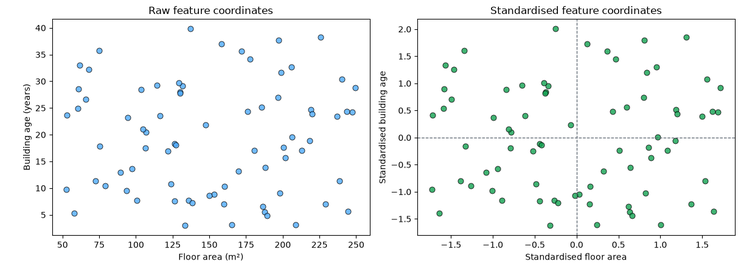

In [9]:
fig, axes = plt.subplots(1, 2, figsize=TWO_PANEL_FIGSIZE)

axes[0].scatter(
    train_features[:, 0],
    train_features[:, 1],
    s=42,
    color=BLUE,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.8,
)
axes[0].set_title("Raw feature coordinates")
axes[0].set_xlabel("Floor area (m²)")
axes[0].set_ylabel("Building age (years)")

axes[1].scatter(
    scaled_train_features[:, 0],
    scaled_train_features[:, 1],
    s=42,
    color=GREEN,
    edgecolor="black",
    linewidth=0.7,
    alpha=0.8,
)
axes[1].axvline(0.0, color=GREY, linewidth=0.9, linestyle="--")
axes[1].axhline(0.0, color=GREY, linewidth=0.9, linestyle="--")
axes[1].set_title("Standardised feature coordinates")
axes[1].set_xlabel("Standardised floor area")
axes[1].set_ylabel("Standardised building age")

fig.tight_layout()
plt.show()

Both panels contain the same 75 training properties. The right panel merely expresses their coordinates relative to each feature's training mean and spread. Dashed lines mark zero after centring; colour is not needed to identify the panels because each has a distinct title and axis labels.


<a id="gradient-descent"></a>
## <font color="#4DAAFC"><strong>6. Build multi-feature gradient descent</strong></font>

We now need a common optimiser with which to compare the two coordinate systems. This section turns the linear prediction, MSE and gradient equations into focused functions, then composes them into one runner. The same implementation will train on raw and standardised inputs.


<a id="regression-parts"></a>
### <font color="#4DAAFC"><strong>6.1 Prediction, loss and gradients</strong></font>

In matrix form, [Equation (2.2)](#equation-2-2) becomes

<a id="equation-6-1"></a>
$$
\style{font-size:1.1em}{
\widehat{\boldsymbol{y}}=X\boldsymbol{w}+b\boldsymbol{1}, \tag{6.1}
}
$$

where $X\in\mathbb{R}^{N\times d}$, $\boldsymbol{w}\in\mathbb{R}^{d}$, $\widehat{\boldsymbol{y}}\in\mathbb{R}^{N}$ and $\boldsymbol{1}\in\mathbb{R}^{N}$ is a vector of ones. NumPy adds scalar $b$ to each element automatically.

Collecting [Equation (2.4)](#equation-2-4) for every feature gives

<a id="equation-6-2"></a>
$$
\style{font-size:1.1em}{
\nabla_{\boldsymbol{w}}J
=\frac{2}{N}X^{\mathsf T}
\left(\widehat{\boldsymbol{y}}-\boldsymbol{y}\right),
\qquad
\frac{\partial J}{\partial b}
=\frac{2}{N}\boldsymbol{1}^{\mathsf T}
\left(\widehat{\boldsymbol{y}}-\boldsymbol{y}\right). \tag{6.2}
}
$$

The weight gradient has shape `(d,)`; the intercept gradient is a scalar.


In [10]:
def validate_regression_inputs(
    feature_matrix: np.ndarray,
    target_vector: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    """Validate aligned regression features and targets.

    Parameters
    ----------
    feature_matrix
        Finite features with shape ``(N, d)``.
    target_vector
        Finite targets with shape ``(N,)``.

    Returns
    -------
    tuple of numpy.ndarray
        Validated floating-point features and targets.
    """
    checked_features = validate_feature_matrix(feature_matrix)
    checked_targets = np.asarray(target_vector, dtype=float)

    if checked_targets.ndim != 1 or checked_targets.size == 0:
        raise ValueError("target_vector must have non-zero shape (N,).")
    if checked_features.shape[0] != checked_targets.size:
        raise ValueError("Features and targets must contain the same observations.")
    if not np.all(np.isfinite(checked_targets)):
        raise ValueError("target_vector must contain only finite values.")

    return checked_features, checked_targets


def linear_predictions(
    feature_matrix: np.ndarray,
    weights: np.ndarray,
    bias: float,
) -> np.ndarray:
    """Calculate linear predictions for a feature matrix.

    Parameters
    ----------
    feature_matrix
        Feature matrix with shape ``(N, d)``.
    weights
        Model weights with shape ``(d,)``.
    bias
        Scalar intercept.

    Returns
    -------
    numpy.ndarray
        Predictions with shape ``(N,)``.
    """
    checked_features = validate_feature_matrix(feature_matrix)
    checked_weights = np.asarray(weights, dtype=float)

    if checked_weights.shape != (checked_features.shape[1],):
        raise ValueError("weights must have shape (d,).")
    if not np.all(np.isfinite(checked_weights)) or not np.isfinite(bias):
        raise ValueError("weights and bias must be finite.")

    return checked_features @ checked_weights + float(bias)


def mean_squared_error(
    observed: np.ndarray,
    predicted: np.ndarray,
) -> float:
    """Calculate the mean squared prediction error.

    Parameters
    ----------
    observed
        Observed targets with shape ``(N,)``.
    predicted
        Predicted targets with shape ``(N,)``.

    Returns
    -------
    float
        Mean of the squared observation-level residuals.
    """
    checked_observed = np.asarray(observed, dtype=float)
    checked_predicted = np.asarray(predicted, dtype=float)

    if checked_observed.shape != checked_predicted.shape or checked_observed.size == 0:
        raise ValueError("observed and predicted must share non-empty shape (N,).")
    if not np.all(np.isfinite(checked_observed)):
        raise ValueError("observed must contain only finite values.")
    if not np.all(np.isfinite(checked_predicted)):
        raise ValueError("predicted must contain only finite values.")

    residuals = checked_predicted - checked_observed
    return float(np.mean(residuals**2))


def linear_loss_and_gradients(
    feature_matrix: np.ndarray,
    target_vector: np.ndarray,
    weights: np.ndarray,
    bias: float,
) -> tuple[float, np.ndarray, float]:
    """Return MSE and its linear-model gradients.

    Parameters
    ----------
    feature_matrix
        Feature matrix with shape ``(N, d)``.
    target_vector
        Target vector with shape ``(N,)``.
    weights
        Current weights with shape ``(d,)``.
    bias
        Current scalar intercept.

    Returns
    -------
    tuple
        Loss, weight gradient with shape ``(d,)`` and scalar bias gradient.
    """
    checked_features, checked_targets = validate_regression_inputs(
        feature_matrix,
        target_vector,
    )
    predictions = linear_predictions(checked_features, weights, bias)
    residuals = predictions - checked_targets
    n_rows = checked_features.shape[0]

    loss = float(np.mean(residuals**2))
    weight_gradient = (2.0 / n_rows) * (checked_features.T @ residuals)
    bias_gradient = float(2.0 * residuals.mean())
    return loss, weight_gradient, bias_gradient

In [11]:
initial_weights = np.zeros(train_features.shape[1])
initial_bias = 0.0

raw_initial_loss, raw_initial_dw, raw_initial_db = linear_loss_and_gradients(
    train_features,
    train_targets,
    initial_weights,
    initial_bias,
)
scaled_initial_loss, scaled_initial_dw, scaled_initial_db = linear_loss_and_gradients(
    scaled_train_features,
    train_targets,
    initial_weights,
    initial_bias,
)

print(f"Shared initial loss:      {raw_initial_loss:,.3f}")
print(f"Raw weight gradient:      {raw_initial_dw}")
print(f"Scaled weight gradient:   {scaled_initial_dw}")
print(f"Shared intercept gradient:{raw_initial_db:,.3f}")

  Shared initial loss:      129,022.920
  Raw weight gradient:      [-115358.013  -12130.519]
  Scaled weight gradient:   [-271.31    70.862]
  Shared intercept gradient:-660.119


The starting predictions and loss are identical because both models begin with zero weights and zero intercepts. The weight gradients differ sharply because the raw matrix multiplies residuals by square-metre and year values, while the standardised matrix uses comparable coordinate scales. The intercept gradient is unchanged because scaling affects $X$, not the residuals at this zero-weight starting point.


<a id="runner"></a>
### <font color="#4DAAFC"><strong>6.2 The complete runner</strong></font>

The runner repeatedly applies the generic gradient-descent updates

<a id="equation-6-3"></a>
$$
\style{font-size:1.1em}{
\boldsymbol{w}^{(t+1)}
=\boldsymbol{w}^{(t)}-\alpha\nabla_{\boldsymbol{w}}J,
\qquad
b^{(t+1)}
=b^{(t)}-\alpha\frac{\partial J}{\partial b}, \tag{6.3}
}
$$

where $t$ is the update number and $\alpha>0$ is the learning rate. It reuses the functions already tested above and stops if the loss becomes non-finite or exceeds a generous divergence threshold.


In [12]:
@dataclass(frozen=True)
class GradientDescentResult:
    """Store a fitted linear model and its optimisation trace."""

    weights: np.ndarray
    bias: float
    loss_history: np.ndarray
    completed_without_divergence: bool


def fit_linear_gradient_descent(
    feature_matrix: np.ndarray,
    target_vector: np.ndarray,
    *,
    learning_rate: float,
    n_updates: int,
    divergence_limit: float = 1e30,
) -> GradientDescentResult:
    """Fit multi-feature linear regression with batch gradient descent.

    Parameters
    ----------
    feature_matrix
        Training features with shape ``(N, d)``.
    target_vector
        Training targets with shape ``(N,)``.
    learning_rate
        Positive step-size multiplier.
    n_updates
        Positive maximum number of parameter updates.
    divergence_limit
        Loss above which the demonstration stops safely.

    Returns
    -------
    GradientDescentResult
        Final parameters, recorded losses and stability status.
    """
    checked_features, checked_targets = validate_regression_inputs(
        feature_matrix,
        target_vector,
    )
    if not np.isfinite(learning_rate) or learning_rate <= 0.0:
        raise ValueError("learning_rate must be finite and positive.")
    if not isinstance(n_updates, int) or n_updates <= 0:
        raise ValueError("n_updates must be a positive integer.")

    weights = np.zeros(checked_features.shape[1], dtype=float)
    bias = 0.0
    recorded_losses: list[float] = []
    stable = True

    for _ in range(n_updates):
        loss, weight_gradient, bias_gradient = linear_loss_and_gradients(
            checked_features,
            checked_targets,
            weights,
            bias,
        )
        recorded_losses.append(loss)

        if not np.isfinite(loss) or loss > divergence_limit:
            stable = False
            break

        weights = weights - learning_rate * weight_gradient
        bias = bias - learning_rate * bias_gradient

    return GradientDescentResult(
        weights=weights,
        bias=bias,
        loss_history=np.asarray(recorded_losses),
        completed_without_divergence=stable,
    )

<a id="comparison"></a>
## <font color="#4DAAFC"><strong>7. Compare raw and scaled optimisation</strong></font>

We can now isolate the effect of coordinate scale: the observations, targets, model, initial parameters and optimiser remain the same; only the representation of the two feature columns changes. We first use one shared learning rate, then give the raw model a much smaller rate and finally quantify the geometry with a condition number.


<a id="same-rate"></a>
### <font color="#4DAAFC"><strong>7.1 The same learning rate</strong></font>

A learning rate of `0.1` is reasonable for the standardised coordinates. Applying it unchanged to raw square metres and years tests whether a single step size can cope with both scales.


In [13]:
shared_learning_rate = 0.1

raw_shared_rate = fit_linear_gradient_descent(
    train_features,
    train_targets,
    learning_rate=shared_learning_rate,
    n_updates=100,
)
scaled_shared_rate = fit_linear_gradient_descent(
    scaled_train_features,
    train_targets,
    learning_rate=shared_learning_rate,
    n_updates=100,
)

print(
    "Raw coordinates:   "
    f"{raw_shared_rate.loss_history.size} losses recorded; "
    f"stable={raw_shared_rate.completed_without_divergence}"
)
print(
    "Scaled coordinates:"
    f"{scaled_shared_rate.loss_history.size} losses recorded; "
    f"stable={scaled_shared_rate.completed_without_divergence}"
)
print(f"Scaled final loss: {scaled_shared_rate.loss_history[-1]:,.3f}")

  Raw coordinates:   5 losses recorded; stable=False
  Scaled coordinates:100 losses recorded; stable=True
  Scaled final loss: 326.921


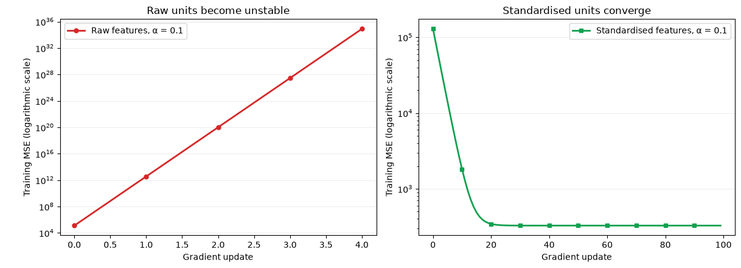

In [14]:
fig, axes = plt.subplots(1, 2, figsize=TWO_PANEL_FIGSIZE)

raw_updates = np.arange(raw_shared_rate.loss_history.size)
scaled_updates = np.arange(scaled_shared_rate.loss_history.size)

axes[0].plot(
    raw_updates,
    raw_shared_rate.loss_history,
    color=RED,
    marker="o",
    markersize=5.0,
    linewidth=2.0,
    label="Raw features, α = 0.1",
)
axes[0].set_title("Raw units become unstable")
axes[0].set_xlabel("Gradient update")
axes[0].set_ylabel("Training MSE (logarithmic scale)")
axes[0].set_yscale("log")
axes[0].legend()

axes[1].plot(
    scaled_updates,
    scaled_shared_rate.loss_history,
    color=GREEN,
    marker="s",
    markevery=10,
    markersize=4.5,
    linewidth=2.0,
    label="Standardised features, α = 0.1",
)
axes[1].set_title("Standardised units converge")
axes[1].set_xlabel("Gradient update")
axes[1].set_ylabel("Training MSE (logarithmic scale)")
axes[1].set_yscale("log")
axes[1].legend()

for axis in axes:
    axis.grid(axis="y", color="#D0D7DE", linewidth=0.6, alpha=0.55)

fig.tight_layout()
plt.show()

The raw-feature loss rises so quickly that the safety threshold stops the run after only a few recorded values. The standardised-feature loss falls smoothly under the same learning rate. The logarithmic vertical axes accommodate large changes in loss; the panel titles, marker shapes and labels communicate the distinction without relying on colour alone.


<a id="safe-rate"></a>
### <font color="#4DAAFC"><strong>7.2 A safer raw-feature rate</strong></font>

Raw features can still be fitted with gradient descent, but this example needs a far smaller learning rate. We compare `10,000` raw-coordinate updates at `0.00001` with `100` standardised-coordinate updates at `0.1`. The comparison is illustrative rather than a universal speed benchmark.


In [15]:
raw_safe_rate = fit_linear_gradient_descent(
    train_features,
    train_targets,
    learning_rate=1e-5,
    n_updates=10_000,
)

print(f"Raw safe-rate final loss: {raw_safe_rate.loss_history[-1]:,.3f}")
print(f"Scaled final loss:        {scaled_shared_rate.loss_history[-1]:,.3f}")
print(f"Raw updates:              {raw_safe_rate.loss_history.size:,}")
print(f"Scaled updates:           {scaled_shared_rate.loss_history.size:,}")

  Raw safe-rate final loss: 458.101
  Scaled final loss:        326.921
  Raw updates:              10,000
  Scaled updates:           100


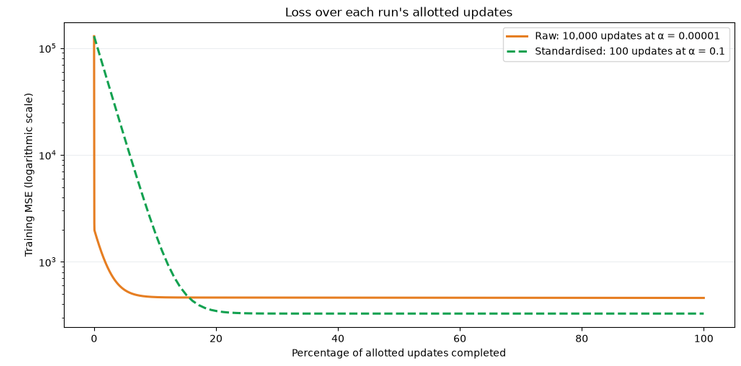

In [16]:
fig, ax = plt.subplots(figsize=SINGLE_PLOT_FIGSIZE)

raw_progress = np.linspace(0.0, 100.0, raw_safe_rate.loss_history.size)
scaled_progress = np.linspace(0.0, 100.0, scaled_shared_rate.loss_history.size)

ax.plot(
    raw_progress,
    raw_safe_rate.loss_history,
    color=ORANGE,
    linewidth=2.2,
    label="Raw: 10,000 updates at α = 0.00001",
)
ax.plot(
    scaled_progress,
    scaled_shared_rate.loss_history,
    color=GREEN,
    linewidth=2.2,
    linestyle="--",
    label="Standardised: 100 updates at α = 0.1",
)
ax.set_title("Loss over each run's allotted updates")
ax.set_xlabel("Percentage of allotted updates completed")
ax.set_ylabel("Training MSE (logarithmic scale)")
ax.set_yscale("log")
ax.grid(axis="y", color="#D0D7DE", linewidth=0.6, alpha=0.55)
ax.legend()
plt.show()

The standardised run reaches a lower loss in far fewer updates. The horizontal axis is each run's percentage of allotted updates—not equal computational time—so the update counts remain in the legend and printed output. The raw model spends many updates adjusting an intercept whose useful scale is very different from that of its feature-weight gradients.


<a id="conditioning"></a>
### <font color="#4DAAFC"><strong>7.3 Conditioning</strong></font>

The condition number offers a compact diagnostic of this geometric imbalance. For linear least squares, form an augmented design matrix $A=[\boldsymbol{1}\;X]$ so that the intercept and features sit in one matrix. We inspect

<a id="equation-7-1"></a>
$$
\style{font-size:1.1em}{
\kappa(A^{\mathsf T}A)
=\frac{\sigma_{\max}(A^{\mathsf T}A)}
{\sigma_{\min}(A^{\mathsf T}A)}, \tag{7.1}
}
$$

where $\kappa$ is the condition number and $\sigma_{\max}$ and $\sigma_{\min}$ are the largest and smallest singular values. A value near one indicates comparably scaled directions; a very large value indicates that some directions are far steeper than others. This number is a diagnostic, not a guarantee of model quality.


In [17]:
def design_condition_number(feature_matrix: np.ndarray) -> float:
    """Return the condition number of the augmented Gram matrix.

    Parameters
    ----------
    feature_matrix
        Feature matrix with shape ``(N, d)``.

    Returns
    -------
    float
        Condition number of ``A.T @ A``, where ``A`` includes an
        intercept column.
    """
    checked = validate_feature_matrix(feature_matrix)
    augmented = np.column_stack([np.ones(checked.shape[0]), checked])
    gram_matrix = augmented.T @ augmented
    return float(np.linalg.cond(gram_matrix))


raw_condition = design_condition_number(train_features)
scaled_condition = design_condition_number(scaled_train_features)

print(f"Raw condition number:   {raw_condition:,.1f}")
print(f"Scaled condition number:{scaled_condition:,.3f}")

  Raw condition number:   307,800.0
  Scaled condition number:1.020


The raw augmented system has a much larger condition number. After standardisation, the intercept and feature directions are far more balanced in this example, which helps one learning rate make useful progress across all coordinates.


<a id="original-units"></a>
## <font color="#4DAAFC"><strong>8. Return to original units</strong></font>

Standardised coefficients are convenient for optimisation but less direct to explain to a client. This section derives an exact conversion back to square metres and years, allowing us to keep the numerical benefits while reporting familiar units.

A fitted scaled model predicts

$$
\style{font-size:1.1em}{
\widehat{y}
=b_z+\sum_{j=1}^{d}w_{z,j}z_j.
}
$$

Substitute the generic standardisation rule from [Equation (3.3)](#equation-3-3):

$$
\style{font-size:1.1em}{
\widehat{y}
=b_z+\sum_{j=1}^{d}w_{z,j}
\frac{x_j-\mu_j}{s_j}.
}
$$

Distribute each scaled weight:

$$
\style{font-size:1.1em}{
\widehat{y}
=b_z
+\sum_{j=1}^{d}\frac{w_{z,j}}{s_j}x_j
-\sum_{j=1}^{d}\frac{w_{z,j}\mu_j}{s_j}.
}
$$

Matching this with the original-unit model $\widehat{y}=b_x+\sum_j w_{x,j}x_j$ gives

<a id="equation-8-1"></a>
$$
\style{font-size:1.1em}{
w_{x,j}=\frac{w_{z,j}}{s_j},
\qquad
b_x=b_z-\sum_{j=1}^{d}\frac{w_{z,j}\mu_j}{s_j}. \tag{8.1}
}
$$

The subscripts $z$ and $x$ distinguish standardised-coordinate and original-coordinate parameters. The two parameterisations must produce the same predictions, apart from floating-point rounding.


In [18]:
def coefficients_in_original_units(
    scaled_weights: np.ndarray,
    scaled_bias: float,
    fitted_standardiser: FeatureStandardiser,
) -> tuple[np.ndarray, float]:
    """Convert standardised linear coefficients to original units.

    Parameters
    ----------
    scaled_weights
        Weights fitted to standardised features with shape ``(d,)``.
    scaled_bias
        Intercept fitted to standardised features.
    fitted_standardiser
        Means and scales used to standardise the features.

    Returns
    -------
    tuple
        Original-unit weights with shape ``(d,)`` and scalar intercept.
    """
    checked_weights = np.asarray(scaled_weights, dtype=float)
    if checked_weights.shape != fitted_standardiser.mean.shape:
        raise ValueError("scaled_weights must match the fitted feature shape.")

    original_weights = checked_weights / fitted_standardiser.scale
    original_bias = float(
        scaled_bias - np.sum(original_weights * fitted_standardiser.mean)
    )
    return original_weights, original_bias


original_weights, original_bias = coefficients_in_original_units(
    scaled_shared_rate.weights,
    scaled_shared_rate.bias,
    standardiser,
)

print(f"Original-unit weights: {original_weights}")
print(f"Original-unit intercept:{original_bias:.3f}")

  Original-unit weights: [ 2.386 -3.627]
  Original-unit intercept:39.680


The first weight is the model's estimated change in thousands of pounds for one additional square metre when age is held fixed. The second is the estimated change for one additional year when area is held fixed. Because the dataset is synthetic and noisy, these estimates need not equal the exact values used to generate every observation.


<a id="evaluation"></a>
## <font color="#4DAAFC"><strong>9. Evaluate on untouched test data</strong></font>

The final model should now be evaluated on observations that did not determine either the model parameters or the scaling statistics. We calculate predictions in both coordinate systems to verify the coefficient conversion, then report test MSE and visualise observed against predicted values.


In [19]:
scaled_test_predictions = linear_predictions(
    scaled_test_features,
    scaled_shared_rate.weights,
    scaled_shared_rate.bias,
)
original_unit_test_predictions = linear_predictions(
    test_features,
    original_weights,
    original_bias,
)

prediction_difference = np.max(
    np.abs(scaled_test_predictions - original_unit_test_predictions)
)
test_mse = mean_squared_error(test_targets, scaled_test_predictions)

print(f"Test MSE:                         {test_mse:,.3f}")
print(f"Maximum parameterisation difference:{prediction_difference:.3e}")

  Test MSE:                         305.583
  Maximum parameterisation difference:1.137e-13


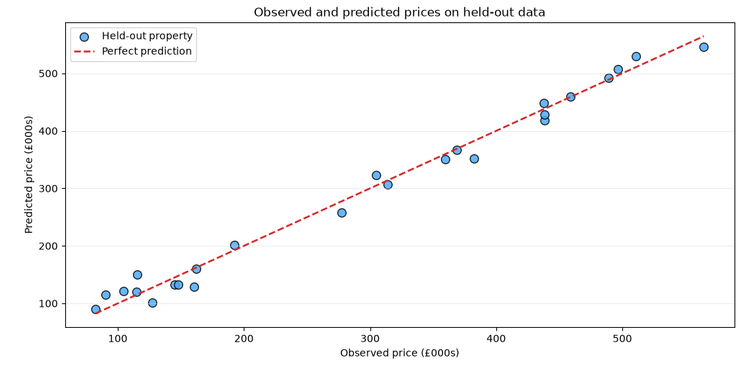

In [20]:
plot_minimum = min(test_targets.min(), scaled_test_predictions.min())
plot_maximum = max(test_targets.max(), scaled_test_predictions.max())

fig, ax = plt.subplots(figsize=SINGLE_PLOT_FIGSIZE)
ax.scatter(
    test_targets,
    scaled_test_predictions,
    s=70,
    color=BLUE,
    edgecolor="black",
    linewidth=1.0,
    alpha=0.85,
    label="Held-out property",
)
ax.plot(
    [plot_minimum, plot_maximum],
    [plot_minimum, plot_maximum],
    color=RED,
    linewidth=1.8,
    linestyle="--",
    label="Perfect prediction",
)
ax.set_title("Observed and predicted prices on held-out data")
ax.set_xlabel("Observed price (£000s)")
ax.set_ylabel("Predicted price (£000s)")
ax.grid(axis="y", color="#D0D7DE", linewidth=0.6, alpha=0.55)
ax.legend()
plt.show()

Each circle is one held-out property; the dashed diagonal shows where prediction would equal observation. Vertical distance from that line represents prediction error. The plot supports interpretation of this synthetic test split only—it is not evidence of performance in a real housing market.


<a id="checks"></a>
## <font color="#4DAAFC"><strong>10. Sanity checks, limitations and next steps</strong></font>

A clean execution is necessary but not sufficient. This final section checks the mathematical invariants on which the workflow depends, identifies what the demonstration cannot establish and gathers the core equations into one route through the lesson.


<a id="sanity-checks"></a>
### <font color="#4DAAFC"><strong>10.1 Sanity checks</strong></font>

The assertions below verify the hand calculation, training-scale properties, reversible feature transform, equivalent prediction parameterisations, finite optimisation output and expected failure for a constant feature.


In [21]:
np.testing.assert_allclose(
    hand_standardised[0],
    np.array([-1.22474487, 1.22474487]),
    rtol=1e-7,
)
np.testing.assert_allclose(scaled_train_features.mean(axis=0), 0.0, atol=1e-12)
np.testing.assert_allclose(scaled_train_features.std(axis=0), 1.0, atol=1e-12)
np.testing.assert_allclose(reconstructed_train_features, train_features)
np.testing.assert_allclose(
    scaled_test_predictions,
    original_unit_test_predictions,
    rtol=1e-12,
    atol=1e-12,
)
assert np.all(np.isfinite(scaled_shared_rate.loss_history))
assert scaled_shared_rate.loss_history[-1] < scaled_shared_rate.loss_history[0]

try:
    fit_standardiser(np.ones((4, 2)))
except ValueError as error:
    constant_feature_check = str(error)
else:
    raise AssertionError("A constant feature should be rejected.")

print("All numerical checks passed.")
print(f"Constant-feature safeguard: {constant_feature_check}")

  All numerical checks passed.
  Constant-feature safeguard: Each feature must have a non-zero standard deviation.


<a id="limitations"></a>
### <font color="#4DAAFC"><strong>10.2 Limitations</strong></font>

- **Synthetic evidence:** the data demonstrate optimisation mechanics, not real housing relationships or deployment performance.
- **One scaling method:** robust scaling may be preferable with strong outliers; min-max scaling may suit a bounded representation. Those methods answer related but different questions.
- **Model dependence:** distance-based methods, regularised linear models and neural networks often benefit from scaling. Decision trees usually do not require it because their splits depend on order rather than Euclidean scale.
- **No cure for poor data:** standardisation does not correct missing values, measurement error, non-linearity, omitted variables or an unsuitable objective.
- **Outliers remain influential:** a mean and standard deviation can themselves be affected by extreme values.
- **Coefficients require care:** converting coefficients restores familiar units, but causal interpretation still requires an appropriate research design.
- **Learning-rate comparison:** the chosen rates deliberately reveal the issue in this dataset; they are not universal defaults.


<a id="summary"></a>
### <font color="#4DAAFC"><strong>10.3 Summary and next steps</strong></font>

We followed one connected route:

1. The linear model in [Equation (2.2)](#equation-2-2) combines each feature with a corresponding weight.
2. The weight gradient in [Equation (2.4)](#equation-2-4) contains the feature values, so numerical units affect update magnitudes.
3. [Equations (3.1)](#equation-3-1) and [(3.2)](#equation-3-2) learn each feature's training mean and spread.
4. [Equation (3.3)](#equation-3-3) expresses a value relative to those training statistics.
5. The gradient updates in [Equation (6.3)](#equation-6-3) then operate in more balanced coordinates.
6. [Equation (8.1)](#equation-8-1) converts the fitted model back to original units without changing its predictions.

The central lesson is not that standardisation makes a dataset *better*. It makes the coordinate system more suitable for a shared gradient-descent learning rate in this example, while careful train/test separation keeps the evaluation honest.

**Suggested next Learning Lab:** extend this deterministic full-batch optimiser to **stochastic and mini-batch gradient descent**, where update noise, batch size and reproducible shuffling introduce a new set of practical choices.

<font color="#2563EB"><strong>🍒 CH3RRY PI3 Learning Labs — understand the mechanism, then trust the tool.</strong></font>
